In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.13.0'

In [3]:
weight = 0.7
basis = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(1)
y = weight * X + basis

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

In [5]:
train_split = int(0.8 * len(X))
X_train = X[:train_split]
y_train = y[:train_split]
X_test = X[train_split:]
y_test = y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

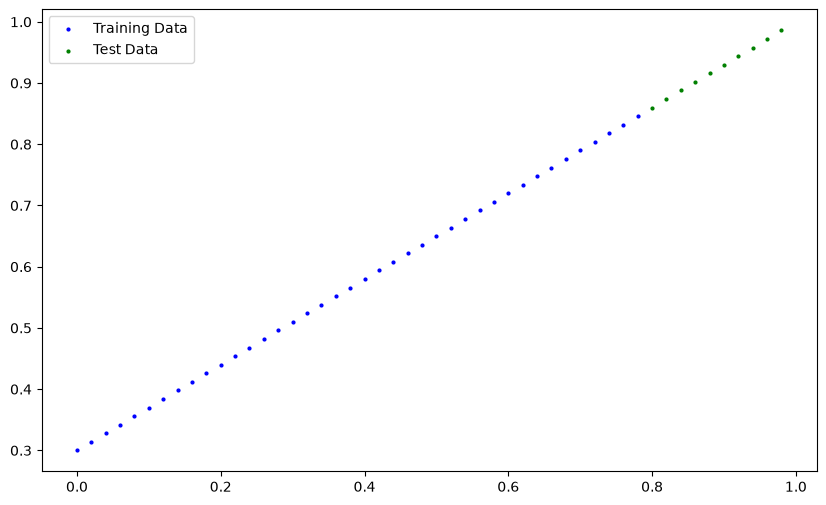

In [6]:
def plot_data(train_data = X_train, train_labels = y_train, test_data = X_test, test_labels = y_test, prediction = None):
    plt.figure(figsize = (10, 6))
    plt.scatter(train_data, train_labels, c = "b", s=4, label = 'Training Data')
    plt.scatter(test_data, test_labels, c = "green", s=4, label = 'Test Data')
    if prediction is not None:
        plt.scatter(test_data, prediction, color = 'red', label = 'Prediction')
    plt.legend()
    plt.show()

plot_data()

In [7]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1),requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1),requires_grad=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.weight + self.bias

In [8]:
torch.manual_seed(42)

model_zero = LinearRegression()

list(model_zero.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
model_zero.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [10]:
X_test

tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

In [11]:
with torch.inference_mode():
    y_pred = model_zero(X_test)

print(y_pred)


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


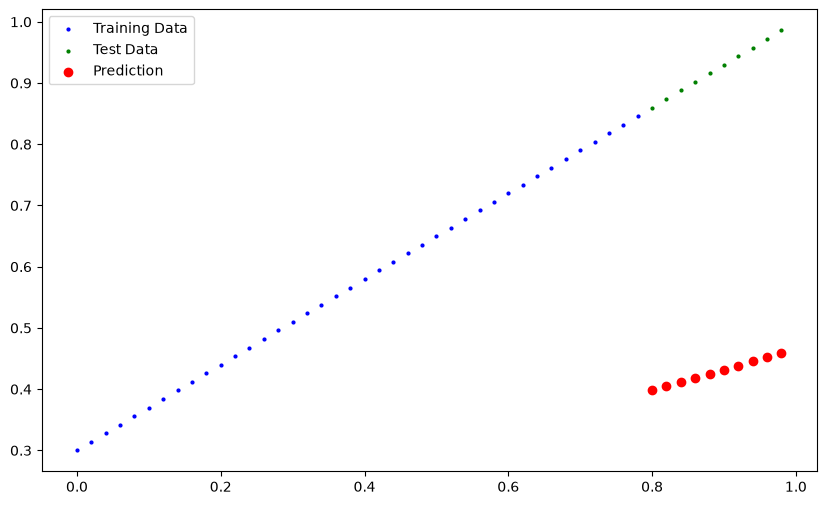

In [12]:
plot_data(prediction=y_pred)

In [13]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(model_zero.parameters(), lr=0.01)

In [14]:
epochs = 1

for epoch in range(epochs):
    model_zero.train()
    y_pred = model_zero(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_zero.eval()
    y_pred = model_zero(X_test)
    loss = loss_fn(y_pred, y_test)
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.4811
